In [5]:
from sklearn.metrics import accuracy_score
from src.NeuralNetwork import NeuralNetwork
import config
import numpy as np
from src.visualize import plot_experiment_summary, plot_grad_over_epochs, save_history

X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")
X_val = np.load("data/X_val.npy")
y_val = np.load("data/y_val.npy")
X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")

X_train = X_train.T  # (784, 49000)
X_val = X_val.T  # (784, 10500)
X_test = X_test.T  # (784, 10500)


print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(784, 49000) (49000,)
(784, 10500) (10500,)
(784, 10500) (10500,)


---

In [6]:
BaselineNN = NeuralNetwork(
    layer_dims=config.LAYER_SIZES,
    activations=config.ACTIVATIONS,
    Weights_initializer="random_normal",
    seed=42,
    use_batchnorm=False,  # Tắt BN để đánh giá đúng baseline
)
BaselineNN.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=config.LEARNING_RATE,
    epochs=config.NUM_EPOCHS,
    batch_size=config.BATCH_SIZE,
)

Epoch: 10
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 20
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 30
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 40
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 50
Accuracy: 0.11253061224489797
val_acc: 0.1126


In [7]:
IniWeight_NN = NeuralNetwork(
    layer_dims=config.LAYER_SIZES,
    activations=config.ACTIVATIONS,
    Weights_initializer="he_normal",
    seed=42,
    use_batchnorm=False,
)
IniWeight_NN.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=config.LEARNING_RATE,
    epochs=config.NUM_EPOCHS,
    batch_size=config.BATCH_SIZE,
)

Epoch: 10
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 20
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 30
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 40
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 50
Accuracy: 0.10418367346938776
val_acc: 0.1042


In [8]:
Activation_NN_1 = NeuralNetwork(
    layer_dims=config.LAYER_SIZES,
    activations=config.PIPELINE1,
    Weights_initializer="random_normal",
    seed=42,
    use_batchnorm=False,
)
Activation_NN_1.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=config.LEARNING_RATE,
    epochs=config.NUM_EPOCHS,
    batch_size=config.BATCH_SIZE,
)

Epoch: 10
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 20
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 30
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 40
Accuracy: 0.11253061224489797
val_acc: 0.1126
Epoch: 50
Accuracy: 0.11253061224489797
val_acc: 0.1126


In [9]:
Activation_NN_2 = NeuralNetwork(
    layer_dims=config.LAYER_SIZES,
    activations=config.PIPELINE1,
    Weights_initializer="he_normal_leaky",
    seed=42,
    use_batchnorm=False,
)
Activation_NN_2.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=config.LEARNING_RATE,
    epochs=config.NUM_EPOCHS,
    batch_size=config.BATCH_SIZE,
)

Epoch: 10
Accuracy: 0.9763673469387755
val_acc: 0.9548
Epoch: 20
Accuracy: 0.9873877551020408
val_acc: 0.9618
Epoch: 30
Accuracy: 0.9938367346938776
val_acc: 0.9643
Epoch: 40
Accuracy: 0.9950408163265306
val_acc: 0.9647
Epoch: 50
Accuracy: 0.9959591836734694
val_acc: 0.9649


In [10]:
BatchNorm_NN = NeuralNetwork(
    layer_dims=config.LAYER_SIZES,
    activations=config.ACTIVATIONS,
    Weights_initializer="random_normal",
    seed=42,
    use_batchnorm=True,
)
BatchNorm_NN.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=config.LEARNING_RATE,
    epochs=config.NUM_EPOCHS,
    batch_size=config.BATCH_SIZE,
)

Epoch: 10
Accuracy: 0.9754693877551021
val_acc: 0.9660
Epoch: 20
Accuracy: 0.9877755102040816
val_acc: 0.9691
Epoch: 30
Accuracy: 0.9943673469387755
val_acc: 0.9744
Epoch: 40
Accuracy: 0.9968979591836735
val_acc: 0.9755
Epoch: 50
Accuracy: 0.9979591836734694
val_acc: 0.9760


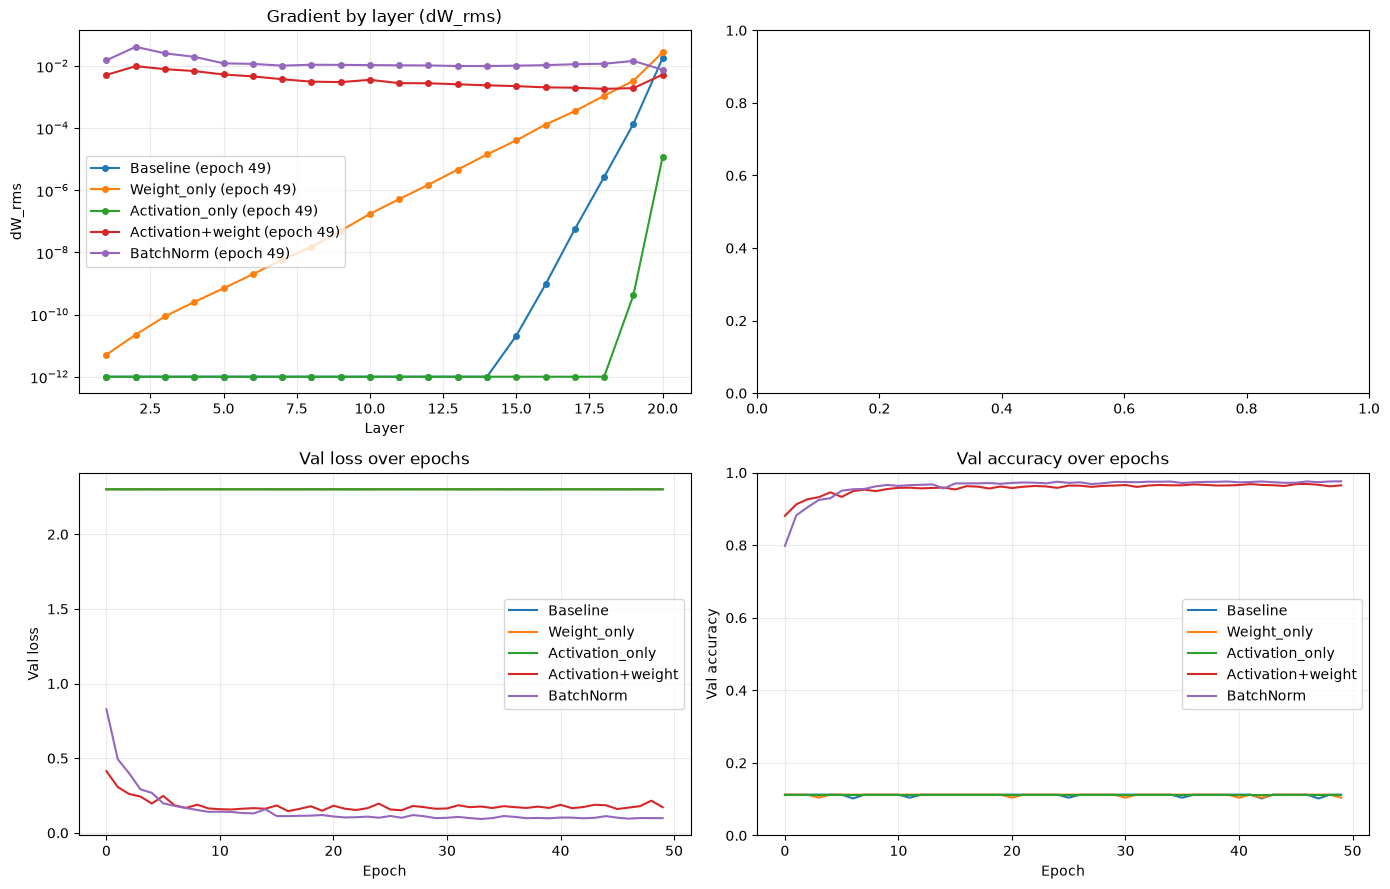

In [12]:
histories = {
    "Baseline": BaselineNN.get_history(),
    "Weight_only":IniWeight_NN.get_history(),
    "Activation_only":Activation_NN_1.get_history(),
    "Activation+weight":Activation_NN_2.get_history(),
    "BatchNorm":BatchNorm_NN.get_history()
}

# Dashboard 4 plot (grad-by-layer, loss, acc)
fig, axes = plot_experiment_summary(histories, epoch=-1, key="dW_rms")

In [ ]:
import itertools
import matplotlib.pyplot as plt

from src.NeuralNetwork import NeuralNetwork
from src.visualize import (
    plot_experiment_summary,
    plot_grad_by_layer,
    plot_loss_over_epochs,
    plot_acc_over_epochs,
    plot_grad_over_epochs,
)
import config

INIT_METHODS = ["random_normal", "xavier_normal", "he_normal", "he_normal_leaky"]
ACTIVATIONS = ["relu", "leaky_relu", "elu", "sigmoid", "tanh"]  # bỏ none, softmax

PRINT_EVERY = 10  # config.py chưa có, tự đặt ở đây


def make_hidden_activations(n_layer, hidden_activation):
    # n_layer lớp có trọng số (hidden + output); output luôn là softmax
    return [hidden_activation] * (n_layer - 1) + ["softmax"] #đã tự thêm none khi xử lý trong class NN


def train_pipeline(name, init_method, hidden_activation, use_batchnorm):
    model = NeuralNetwork(
        config.LAYER_SIZES,
        activations=make_hidden_activations(config.NUM_LAYERS, hidden_activation),
        Weights_initializer=init_method,
        seed=config.SEED,
        use_batchnorm=use_batchnorm,
    )
    model.fit(
        X_train, y_train, X_val, y_val,
        learning_rate=config.LEARNING_RATE,
        epochs=config.NUM_EPOCHS,
        batch_size=config.BATCH_SIZE,
        print_every=PRINT_EVERY,
    )
    print(f"=== Done: {name} ===\n")
    return model.get_history()


histories = {}

# --- 20 pipeline: 4 init x 5 activation (đã bao gồm baseline random_normal+sigmoid) ---
for init_method, activation in itertools.product(INIT_METHODS, ACTIVATIONS):
    print(f"Bắt đầu train model với method:{init_method} + activation:{activation}")
    name = f"{init_method} + {activation}"
    histories[name] = train_pipeline(
        name, init_method=init_method, hidden_activation=activation,
        use_batchnorm=False,  # mặc định bật BN cho lưới chính
    )

# --- +1 BatchNorm: random_normal + sigmoid, nhấn mạnh so sánh Baseline vs BN ---
histories["BatchNorm"] = train_pipeline(
    "BatchNorm", init_method="random_normal", hidden_activation="sigmoid",
    use_batchnorm=True,
)

print(f"Tổng số pipeline: {len(histories)}")  # phải ra 21

Bắt đầu train model với method:random_normal + activation:relu
Epoch: 10
Accuracy: 0.9760408163265306
val_acc: 0.9628
Epoch: 20
Accuracy: 0.987265306122449
val_acc: 0.9732
Epoch: 30
Accuracy: 0.9939183673469387
val_acc: 0.9752
Epoch: 40
Accuracy: 0.9942244897959184
val_acc: 0.9742
Epoch: 50
Accuracy: 0.9877142857142858
val_acc: 0.9662
=== Done: random_normal + relu ===

Bắt đầu train model với method:random_normal + activation:leaky_relu
Epoch: 10
Accuracy: 0.973530612244898
val_acc: 0.9631
Epoch: 20
Accuracy: 0.9865510204081632
val_acc: 0.9725
Epoch: 30
Accuracy: 0.9898367346938776
val_acc: 0.9732
Epoch: 40
Accuracy: 0.9955510204081632
val_acc: 0.9767
Epoch: 50
Accuracy: 0.997734693877551
val_acc: 0.9790
=== Done: random_normal + leaky_relu ===

Bắt đầu train model với method:random_normal + activation:elu
Epoch: 10
Accuracy: 0.9856938775510204
val_acc: 0.9708
Epoch: 20
Accuracy: 0.9928979591836735
val_acc: 0.9757
Epoch: 30
Accuracy: 0.9876734693877551
val_acc: 0.9685
Epoch: 40
Accura